# Step 2 — LLM Annotation: Sentiment & Topic Analysis

This notebook explores the results of the LLM annotation pass run by `src/analysis/annotate.py`.
It assumes that:
1. `annotate.py` has been run and `data/processed/llm_annotations/*.jsonl` files exist.
2. `aggregate_features.py` has been run and `data/processed/features/nlp_features.parquet` exists.

**Sections:**
1. Load & inspect raw annotations
2. Sentiment time-series by source and speaker role
3. Topic heatmap across quarters
4. Representative key quotes per topic per quarter
5. Validation sample — manual label spot-check
6. NLP feature summary (what goes into Step 3)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path('..').resolve()))
from src.utils.config import FEATURES_DIR, LLM_ANNOTATIONS_DIR

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

SOURCE_TYPES = ['transcripts', 'news', 'reports_40f', 'reports_quarterly']
TOPICS = [
    'NIM', 'credit_quality', 'capital', 'US_retail', 'Canadian_personal',
    'wealth_wholesale', 'regulatory_AML', 'macro_outlook', 'cost_efficiency',
    'guidance', 'M_and_A', 'other',
]
print('Setup complete')

Setup complete


## 1. Load raw annotations

In [2]:
records = []
for src in SOURCE_TYPES:
    path = LLM_ANNOTATIONS_DIR / f'{src}.jsonl'
    if not path.exists():
        print(f'  {src}: NOT FOUND — run annotate.py first')
        continue
    n = 0
    with path.open() as fh:
        for line in fh:
            try:
                r = json.loads(line)
            except Exception:
                continue
            r['_src'] = src
            r['_sentiment'] = r.get('output', {}).get('sentiment', '')
            r['_score'] = r.get('output', {}).get('sentiment_score', None)
            r['_topics'] = r.get('output', {}).get('topics', [])
            r['_key_quote'] = r.get('output', {}).get('key_quote', '')
            r['_role'] = (r.get('speaker') or {}).get('role', '')
            r['_name'] = (r.get('speaker') or {}).get('name', '')
            records.append(r)
            n += 1
    print(f'  {src}: {n:,} annotations')

df = pd.DataFrame(records)
df['_score'] = pd.to_numeric(df['_score'], errors='coerce')
df['fiscal_quarter'] = df['fiscal_quarter'].fillna(df.get('td_fiscal_quarter_hint', ''))
print(f'\nTotal: {len(df):,} annotated chunks')
df.head(3)

  transcripts: 889 annotations
  news: 1,019 annotations
  reports_40f: 933 annotations
  reports_quarterly: 1,043 annotations

Total: 3,884 annotated chunks


,cache_key,chunk_id,source_type,model,prompt_version,output,date,fiscal_quarter,td_fiscal_quarter_hint,section,speaker,token_count,created_at,_src,_sentiment,_score,_topics,_key_quote,_role,_name
0,959878b2b89674896e1996ca564aaf586b06d0cea4514c...,transcripts:2021-02-25_2021-q1-transcript-f-en...,transcripts,gpt-4o-mini,v1,"{'sentiment': 'neutral', 'sentiment_score': 0....",2021-02-25,FY2021Q1,FY2021-Q1,prepared_remarks,"{'name': 'TD Bank Group', 'role': 'other_exec'...",48,2026-04-19T20:33:32+00:00,transcripts,neutral,0.0,[Canadian_personal],Leadership team includes key executives from v...,other_exec,TD Bank Group
1,76eaa7d9447aae98770a39fddcaccaacb6789a82db688c...,transcripts:2021-02-25_2021-q1-transcript-f-en...,transcripts,gpt-4o-mini,v1,"{'sentiment': 'positive', 'sentiment_score': 0...",2021-02-25,FY2021Q1,FY2021-Q1,prepared_remarks,"{'name': 'Bharat Masrani', 'role': 'ceo', 'aff...",282,2026-04-18T19:50:27+00:00,transcripts,positive,0.8,"[credit_quality, capital, macro_outlook]","TD started the year strong, with significant e...",ceo,Bharat Masrani
2,bf578d7ec87acd1a7668743435d9e4a9577d61242c5ea1...,transcripts:2021-02-25_2021-q1-transcript-f-en...,transcripts,gpt-4o-mini,v1,"{'sentiment': 'positive', 'sentiment_score': 0...",2021-02-25,FY2021Q1,FY2021-Q1,prepared_remarks,"{'name': 'Bharat Masrani', 'role': 'ceo', 'aff...",989,2026-04-18T19:50:27+00:00,transcripts,positive,0.7,"[macro_outlook, Canadian_personal, wealth_whol...",We are seeing evidence of rising consumer and ...,ceo,Bharat Masrani


In [3]:
# Sentiment label distribution by source
pd.crosstab(df['_src'], df['_sentiment'], normalize='index').round(3).style.background_gradient(cmap='RdYlGn', axis=1)

_sentiment,negative,neutral,positive
_src,,,
news,0.053000,0.184000,0.763000
reports_40f,0.078000,0.589000,0.332000
reports_quarterly,0.077000,0.573000,0.350000
transcripts,0.020000,0.462000,0.517000


## 2. Sentiment time-series

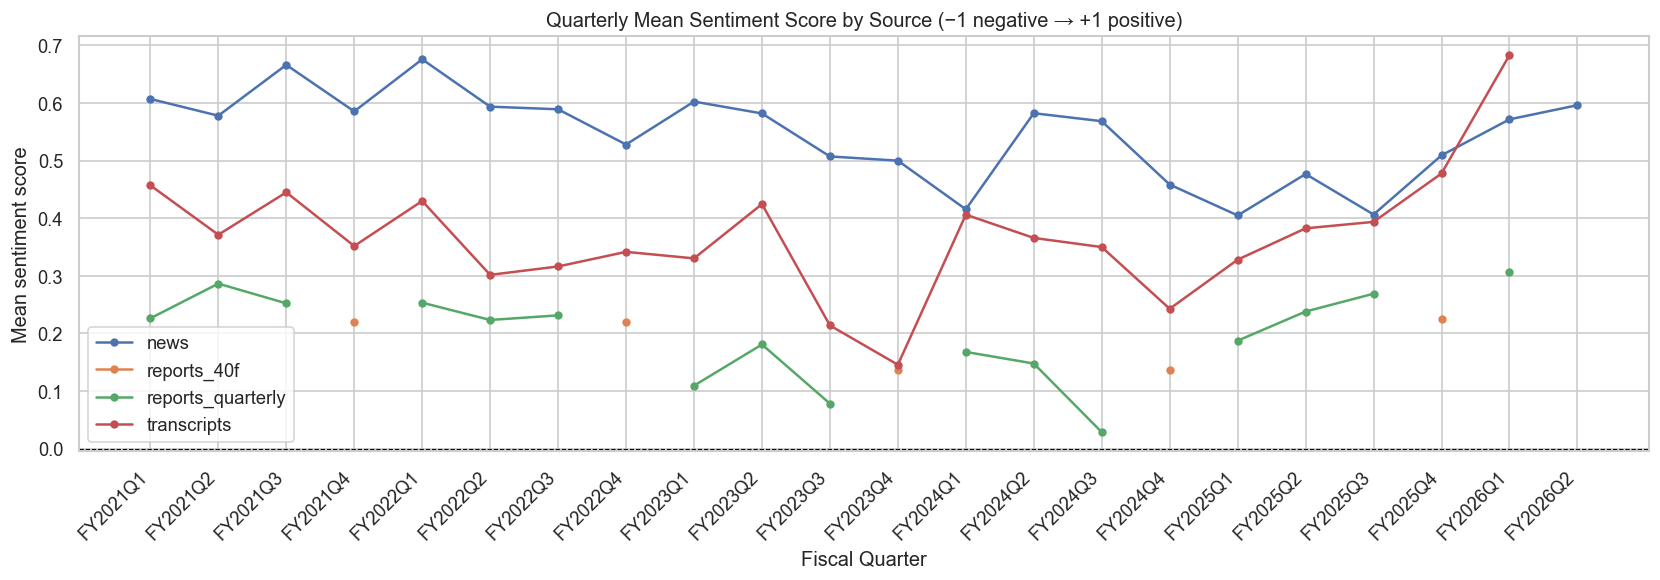

In [4]:
# --- Quarterly mean sentiment by source ---
pivot = (
    df.groupby(['fiscal_quarter', '_src'])['_score']
    .mean()
    .unstack('_src')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker='o', markersize=4, label=col)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_title('Quarterly Mean Sentiment Score by Source (−1 negative → +1 positive)')
ax.set_xlabel('Fiscal Quarter')
ax.set_ylabel('Mean sentiment score')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

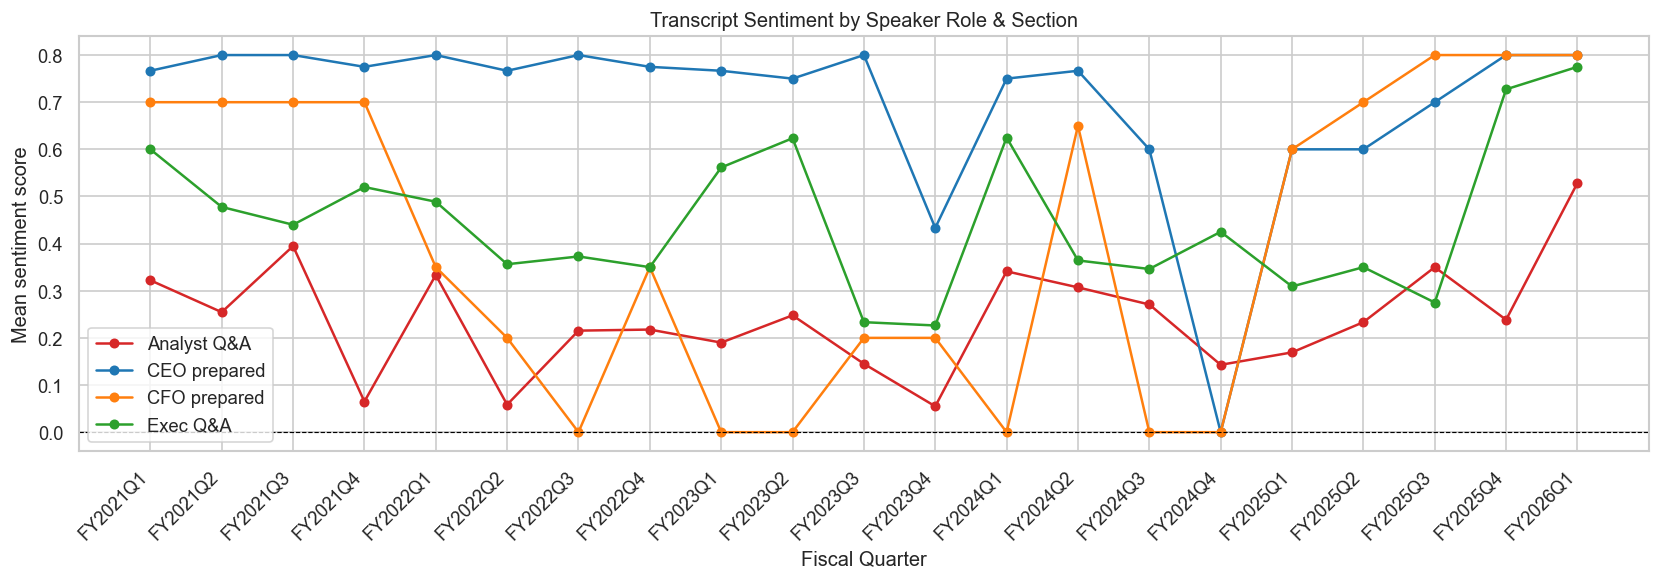

In [5]:
# --- Transcript sentiment split: CEO prep vs CFO prep vs analyst Q&A ---
tr = df[df['_src'] == 'transcripts'].copy()

def role_section_label(row):
    role = row['_role']
    sec = row.get('section', '')
    if sec == 'prepared_remarks' and role == 'ceo':
        return 'CEO prepared'
    if sec == 'prepared_remarks' and role == 'cfo':
        return 'CFO prepared'
    if sec == 'qa' and role == 'analyst':
        return 'Analyst Q&A'
    if sec == 'qa' and role in ('ceo', 'cfo', 'other_exec'):
        return 'Exec Q&A'
    return None

tr['label'] = tr.apply(role_section_label, axis=1)
tr_filtered = tr[tr['label'].notna()]

pivot_tr = (
    tr_filtered.groupby(['fiscal_quarter', 'label'])['_score']
    .mean()
    .unstack('label')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
colors = {'CEO prepared': '#1f77b4', 'CFO prepared': '#ff7f0e',
          'Exec Q&A': '#2ca02c', 'Analyst Q&A': '#d62728'}
for col in pivot_tr.columns:
    ax.plot(pivot_tr.index, pivot_tr[col], marker='o', markersize=5,
            label=col, color=colors.get(col))
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_title('Transcript Sentiment by Speaker Role & Section')
ax.set_xlabel('Fiscal Quarter')
ax.set_ylabel('Mean sentiment score')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Topic heatmap

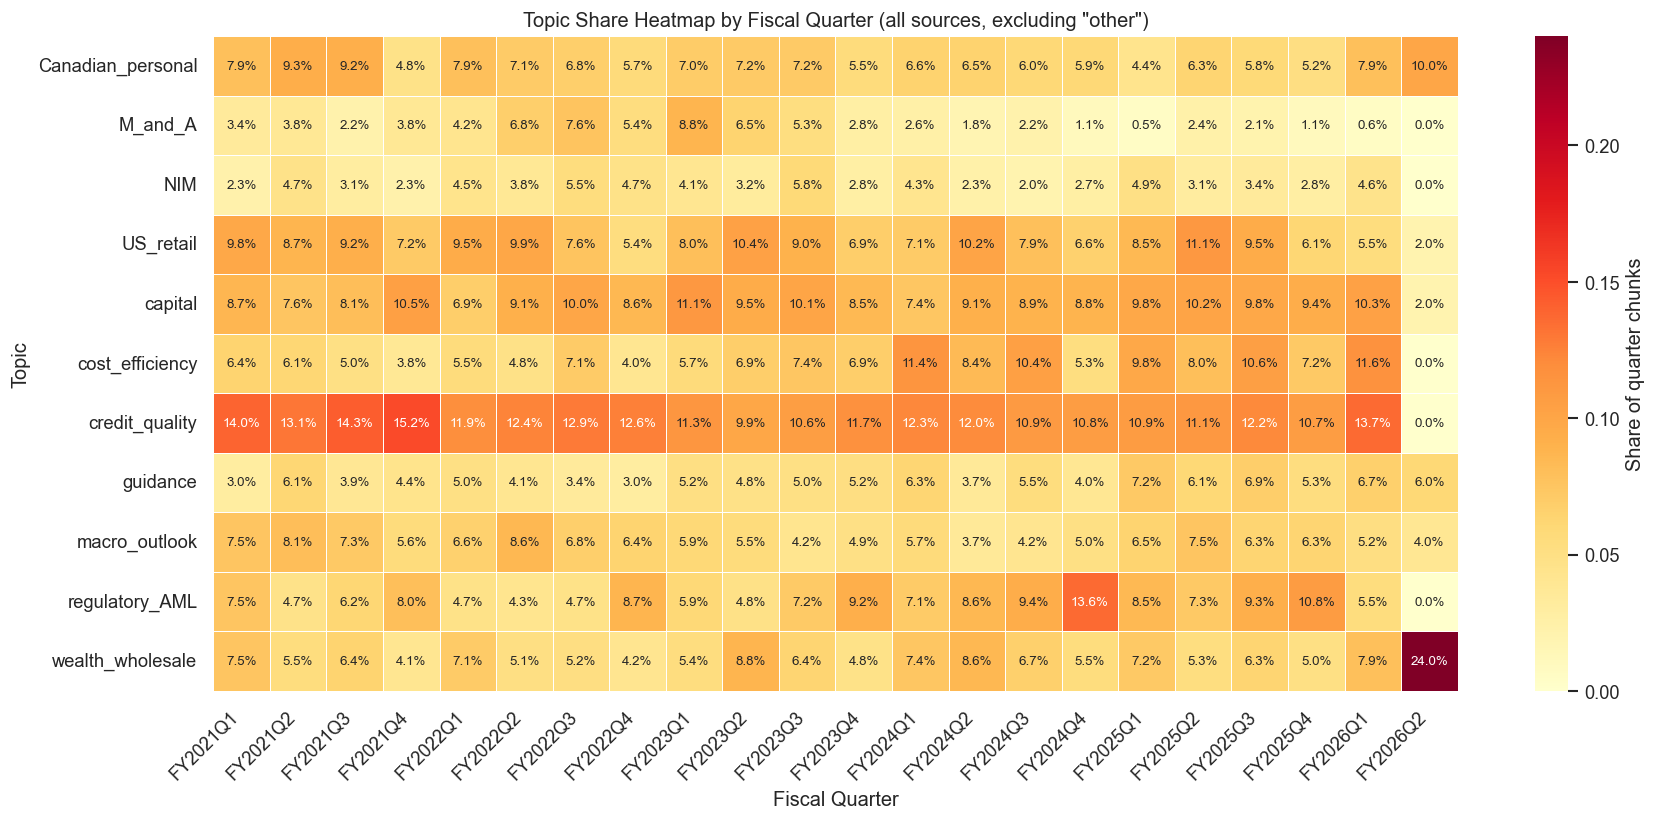

In [6]:
# Explode topics (each chunk can have multiple)
df_topics = df.explode('_topics').rename(columns={'_topics': 'topic'})
df_topics = df_topics[df_topics['topic'].isin(TOPICS)]

topic_heatmap = (
    df_topics.groupby(['fiscal_quarter', 'topic'])
    .size()
    .unstack('topic', fill_value=0)
    .sort_index()
)
# Normalise each row to show share within quarter
topic_heatmap_pct = topic_heatmap.div(topic_heatmap.sum(axis=1), axis=0)

# Drop 'other' from the plot for clarity
cols_to_show = [c for c in topic_heatmap_pct.columns if c != 'other']

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    topic_heatmap_pct[cols_to_show].T,
    ax=ax,
    cmap='YlOrRd',
    fmt='.1%',
    annot=True,
    annot_kws={'size': 8},
    linewidths=0.4,
    cbar_kws={'label': 'Share of quarter chunks'},
)
ax.set_title('Topic Share Heatmap by Fiscal Quarter (all sources, excluding "other")')
ax.set_xlabel('Fiscal Quarter')
ax.set_ylabel('Topic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

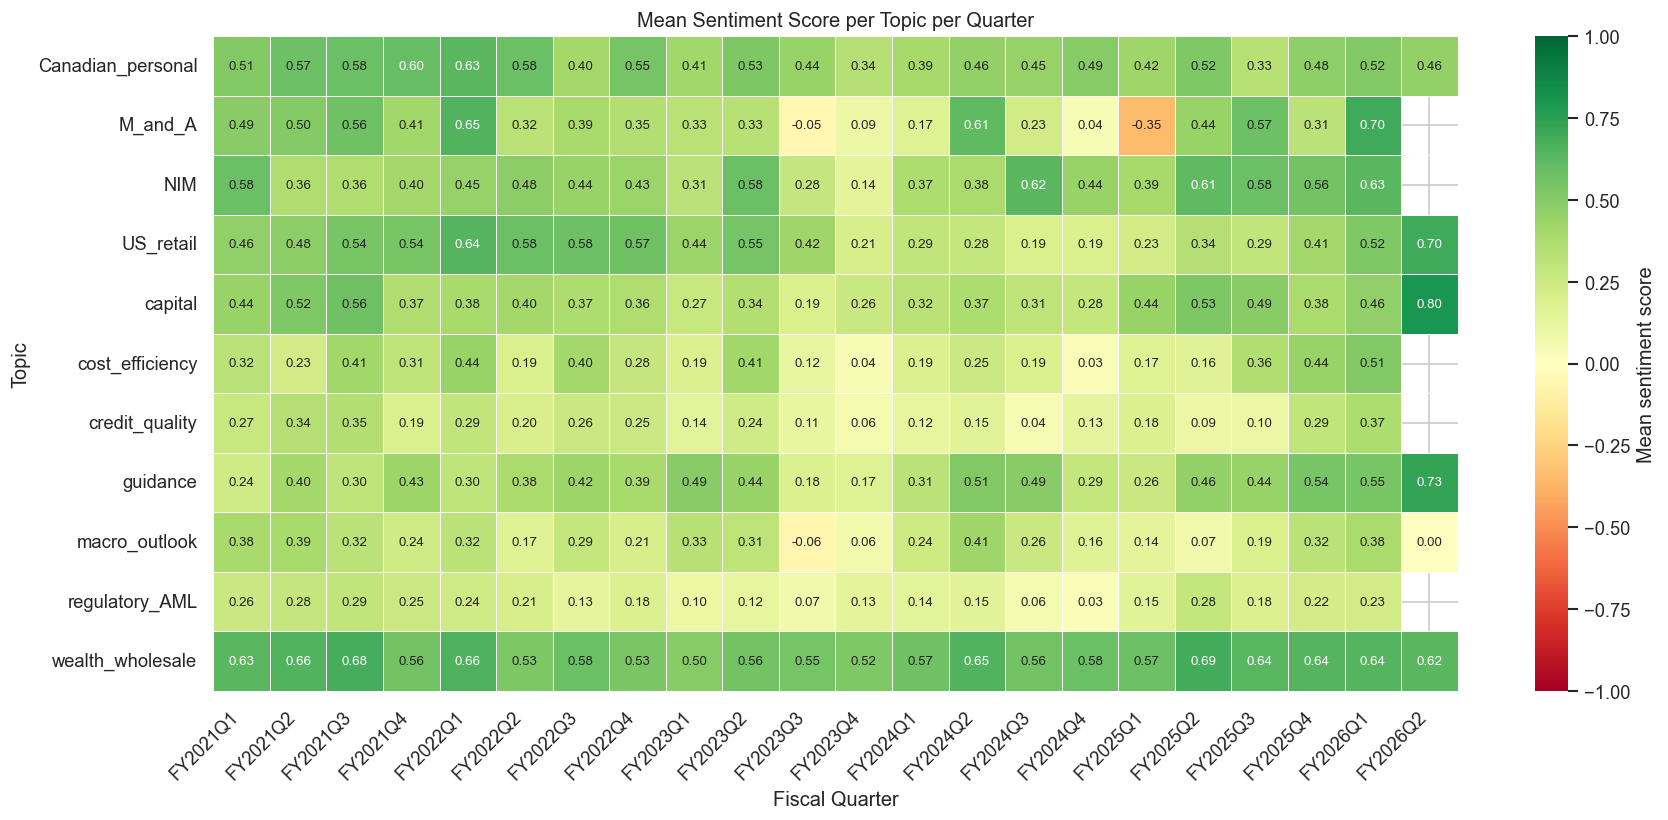

In [7]:
# Topic sentiment heatmap — is the tone around each topic positive or negative?
topic_sentiment = (
    df_topics.groupby(['fiscal_quarter', 'topic'])['_score']
    .mean()
    .unstack('topic')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    topic_sentiment[cols_to_show].T,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    fmt='.2f',
    annot=True,
    annot_kws={'size': 8},
    linewidths=0.4,
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Mean sentiment score'},
)
ax.set_title('Mean Sentiment Score per Topic per Quarter')
ax.set_xlabel('Fiscal Quarter')
ax.set_ylabel('Topic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Representative key quotes per topic

In [8]:
# For each topic, show the most negative and most positive key quote across all quarters
SHOW_TOPICS = ['NIM', 'credit_quality', 'regulatory_AML', 'macro_outlook', 'capital']

for topic in SHOW_TOPICS:
    sub = df_topics[df_topics['topic'] == topic].dropna(subset=['_score', '_key_quote'])
    if sub.empty:
        continue
    most_neg = sub.loc[sub['_score'].idxmin()]
    most_pos = sub.loc[sub['_score'].idxmax()]
    print(f'\n── {topic} ──')
    print(f'  Most positive [{most_pos["fiscal_quarter"]}] ({most_pos["_score"]:+.2f})')
    print(f'  "{most_pos["_key_quote"]}"')
    print(f'  Most negative [{most_neg["fiscal_quarter"]}] ({most_neg["_score"]:+.2f})')
    print(f'  "{most_neg["_key_quote"]}"')


── NIM ──
  Most positive [FY2022Q4] (+0.80)
  "We expect NIM to improve in the near term, assuming that the forward curves hold."
  Most negative [FY2023Q4] (-0.70)
  "Reported net income decreased by 38% compared to last year."

── credit_quality ──
  Most positive [FY2025Q2] (+0.85)
  "Total comprehensive income increased significantly compared to the previous year."
  Most negative [FY2021Q4] (-0.80)
  "The COVID-19 pandemic has negatively impacted the Bank’s results and financial condition."

── regulatory_AML ──
  Most positive [FY2024Q1] (+0.80)
  "TD's US$20 billion community impact plan supports fair lending and community investment."
  Most negative [FY2021Q4] (-0.80)
  "The COVID-19 pandemic has negatively impacted the Bank’s results and financial condition."

── macro_outlook ──
  Most positive [FY2021Q1] (+0.80)
  "TD started the year strong, with significant earnings and improved credit loss provisions."
  Most negative [FY2021Q4] (-0.80)
  "The COVID-19 pandemic has neg

## 5. Validation sample — manual spot-check

Sample 30 chunks (10 each from transcripts, news, reports_quarterly). Review the LLM label and decide if you agree.

In [9]:
# Load the original chunk text alongside annotations for comparison
import json as _json
from src.utils.config import CHUNKS_DIR

chunk_lookup: dict[str, str] = {}
for src in SOURCE_TYPES:
    path = CHUNKS_DIR / f'{src}.jsonl'
    if not path.exists():
        continue
    with path.open() as fh:
        for line in fh:
            try:
                c = _json.loads(line)
                chunk_lookup[c['chunk_id']] = c.get('text', '')[:600]
            except Exception:
                pass

pool = df[df['_src'].isin(['transcripts', 'news', 'reports_quarterly'])].copy()
parts = []
for src_name, grp in pool.groupby('_src'):
    parts.append(grp.sample(min(10, len(grp)), random_state=42))
validation_sample = pd.concat(parts).reset_index(drop=True)

validation_sample['chunk_text_preview'] = validation_sample['chunk_id'].map(
    lambda cid: chunk_lookup.get(cid, '')[:300]
)

display_cols = ['_src', 'fiscal_quarter', '_role', '_sentiment', '_score', '_topics', '_key_quote', 'chunk_text_preview']
validation_sample[display_cols].style.set_properties(**{'text-align': 'left', 'font-size': '11px'})

,_src,fiscal_quarter,_role,_sentiment,_score,_topics,_key_quote,chunk_text_preview
0,news,FY2024Q1,,positive,0.800000,"['wealth_wholesale', 'other']",TD Asset Management Inc. funds were recognized for attractive risk-adjusted returns for the 17th consecutive year.,"TD Asset Management Inc. Recognized in Five Categories at the 2023 Canada LSEG Lipper Fund Awards 9 minute read For the 17 th year in a row, TD Asset Management Inc. funds were recognized for providing attractive risk-adjusted returns, relative to industry peers TORONTO , Nov. 10, 2023 /CNW/ - A"
1,news,FY2023Q3,,positive,0.800000,"['Canadian_personal', 'wealth_wholesale', 'US_retail']",TD Bank Group will host an Investor Day to discuss strategy and growth plans.,"Media Advisory - TD Bank Group to host Investor Day 1 minute read TORONTO , July 7, 2025 /CNW/ - TD Bank Group (""TD"" or the ""Bank"") will host an Investor Day in Toronto on Monday, September 29, 2025 . A live webcast of the event will also be available. The event will feature presentations by Raym"
2,news,FY2023Q3,,positive,0.600000,"['US_retail', 'Canadian_personal', 'wealth_wholesale']",TD's retail businesses showed strong revenue and earnings growth this quarter.,"TD Bank Group Reports Second Quarter 2023 Results 10 minute read Earnings News Release • Three and six months ended April 30, 2023 This quarterly Earnings News Release should be read in conjunction with the Bank's unaudited second quarter 2023 Report to Shareholders for the three and six months e"
3,news,FY2021Q2,,positive,0.700000,"['NIM', 'credit_quality', 'M_and_A']",Canadian Retail reported net income increased by 14% compared to the previous year.,"(millions of Canadian dollars, except as noted) For the three months ended January 31 October 31 January 31 Average common equity $ 89,211 $ 86,883 $ 81,933 Net income available to common shareholders – reported 3,212 5,079 2,922 Items of note, net of income taxes 1 (2,173) Net inc"
4,news,FY2024Q3,,positive,0.800000,"['guidance', 'other']","TD Bank Group will release its second quarter financial results on May 23, 2024.","Media Advisory - TD Bank Group to release second-quarter financial results 2 minute read TORONTO , May 1, 2025 /CNW/ - TD Bank Group (""TD"" or the ""Bank"") will release its second-quarter financial results and host an earnings conference call on Thursday, May 22, 2025 . Financial results will be is"
5,news,FY2024Q2,,negative,-0.600000,"['credit_quality', 'US_retail', 'cost_efficiency']",U.S. Retail Bank reported net income decreased significantly due to higher PCL and non-interest expenses.,"PCL for the quarter was $423 million , an increase of $33 million compared with the prior quarter. PCL – impaired was $364 million , an increase of $90 million , or 33%, reflecting further normalization of credit performance in the consumer lending portfolios, and credit migration in the commercial"
6,news,FY2023Q3,,negative,-0.600000,"['capital', 'M_and_A', 'other']",The Bank recorded a provision of approximately $1.6 billion pre-tax related to the Stanford litigation settlement.,The Bank determined that the fair value of First Horizon's fixed rate financial assets and liabilities and certain intangible assets would have been sensitive to interest rate changes. The fair value of net assets would have determined the amount of goodwill to be recognized on closing of the acquis
7,news,FY2025Q1,,positive,0.700000,['other'],TD Asset Management announces cash distributions for various TD ETFs.,"TD Asset Management Inc. Announces TD ETF Distributions 11 minute read TORONTO , March 19, 2026 /CNW/ - TD Asset Management Inc. (""TDAM"") today announced the March cash distributions for the TD Exchange-Traded Funds (each, a ""TD ETF"" and collectively, the ""TD ETFs"") and TD Mutual Fund ETF Series ("
8,news,FY2021Q3,,positive,0.800000,"['US_retail', 'Canadian_personal', 'wealth_wholesale']",TD is the fifth largest bank in North America by assets.,"For all other shareholder inquiries, please con

## 6. NLP feature summary (Step 3 inputs)

In [10]:
feat_path = FEATURES_DIR / 'nlp_features.parquet'
if not feat_path.exists():
    print('Run aggregate_features.py first: python -m src.analysis.aggregate_features')
else:
    feat = pd.read_parquet(feat_path)
    print(f'Feature matrix: {feat.shape[0]} quarters × {feat.shape[1]} columns')
    feat.head()

Feature matrix: 21 quarters × 36 columns


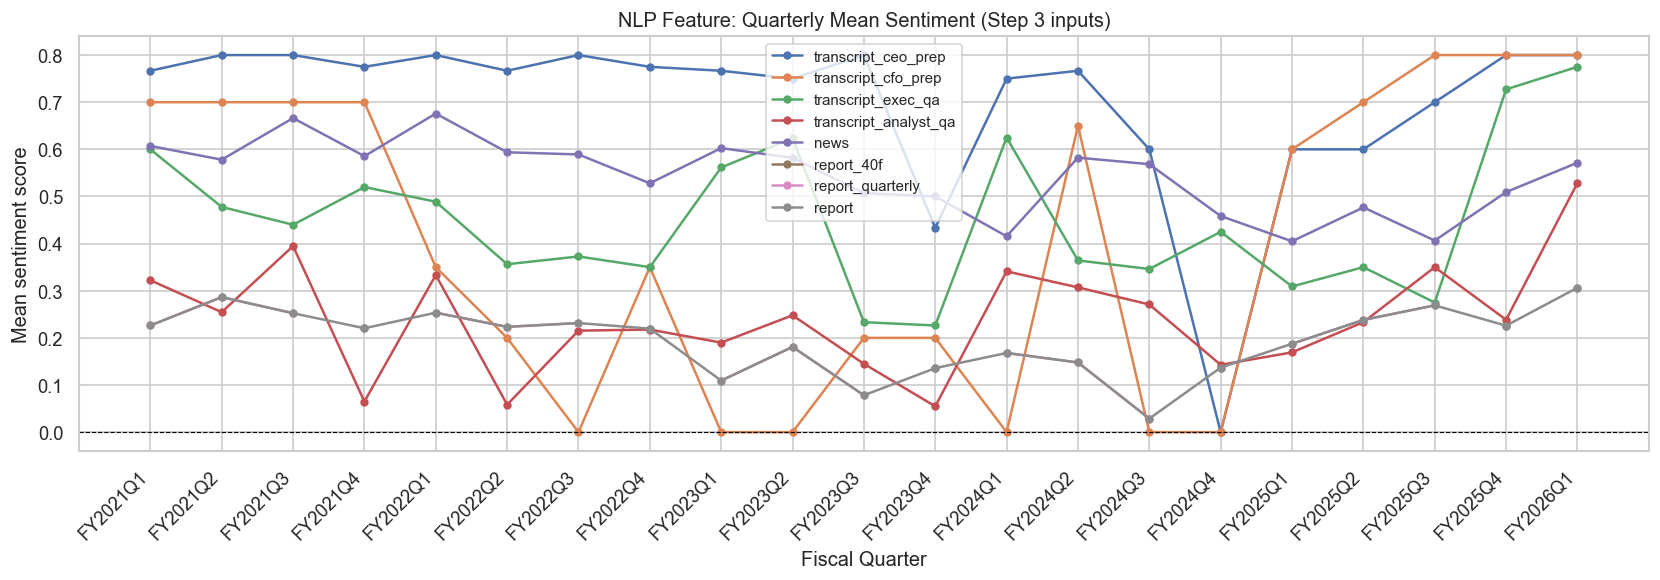

In [11]:
if feat_path.exists():
    # Sentiment columns over time
    sent_cols = [c for c in feat.columns if 'sentiment_mean' in c]
    fig, ax = plt.subplots(figsize=(14, 5))
    for col in sent_cols:
        ax.plot(feat['fiscal_quarter'], feat[col], marker='o', markersize=4, label=col.replace('_sentiment_mean', ''))
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title('NLP Feature: Quarterly Mean Sentiment (Step 3 inputs)')
    ax.set_xlabel('Fiscal Quarter')
    ax.set_ylabel('Mean sentiment score')
    ax.legend(fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

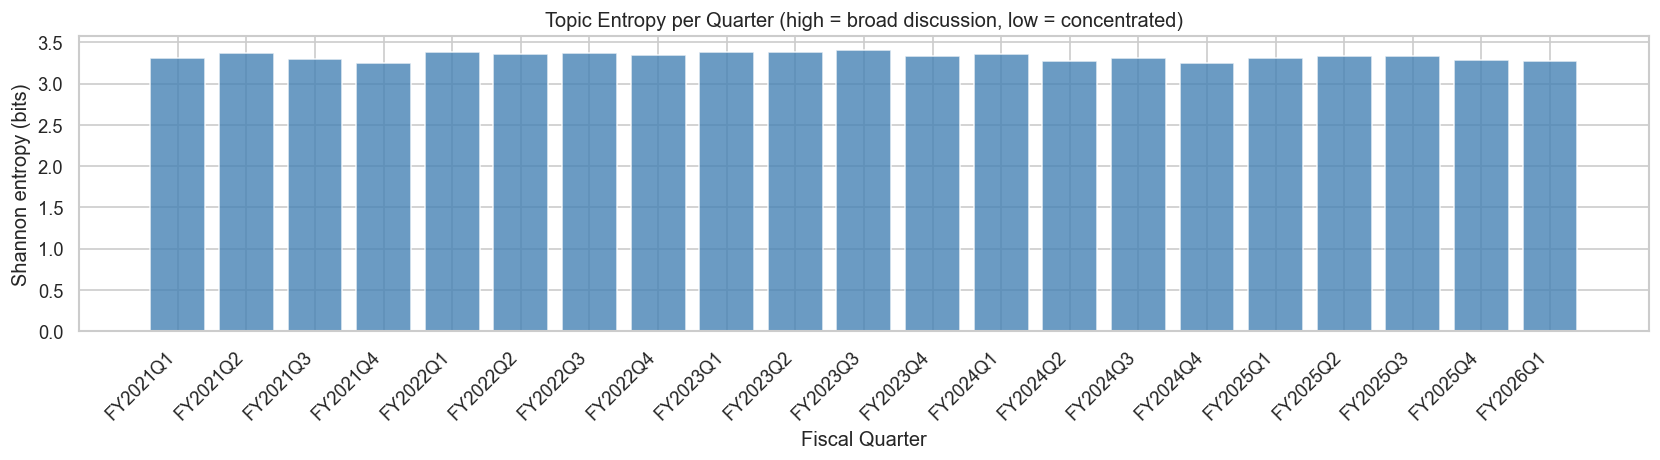

In [12]:
if feat_path.exists():
    # Topic entropy — how concentrated is the narrative each quarter?
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(feat['fiscal_quarter'], feat['topic_entropy'], color='steelblue', alpha=0.8)
    ax.set_title('Topic Entropy per Quarter (high = broad discussion, low = concentrated)')
    ax.set_xlabel('Fiscal Quarter')
    ax.set_ylabel('Shannon entropy (bits)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [13]:
if feat_path.exists():
    # Full feature matrix — show missing values heatmap
    numeric_cols = feat.select_dtypes(include='number').columns
    missing_pct = feat[numeric_cols].isna().mean()
    print('Columns with missing values:')
    print(missing_pct[missing_pct > 0].sort_values(ascending=False).to_string())
    if (missing_pct > 0).sum() == 0:
        print('No missing values — feature matrix is complete.')

Columns with missing values:
report_40f_sentiment_mean          0.761905
report_quarterly_sentiment_mean    0.238095
